# 🏏 Bangla Sports Sentiment Analysis — MNB+CNN+TNN → RF Classifier
## Thesis-Ready Complete Pipeline

**Dataset:** Bangla Sports Sentiment Analysis Dataset  
**Task:** Binary Sentiment Classification (Positive / Negative)  
**Feature Engineering:** TF-IDF Ensemble — MNB (Multinomial N-gram) + CNN (Char N-gram) + TNN (Token N-gram)  
**Classifier:** Random Forest (RF) — Soft Voting Ensemble  
**Author:** [Your Name]  
**Date:** 2026

---

### Pipeline Overview
```
Raw Data → Preprocessing → Feature Engineering
         MNB: Mixed N-gram (char_wb 2-4 + word 1-2)
         CNN: Char N-gram  (char 3-5, char_wb 2-5)
         TNN: Token N-gram (word 1-3)
         → Concatenated Feature Matrix
         → Random Forest (RF) × 3 Heads
         → Soft Voting Ensemble
         → Evaluation → Thesis Diagrams & Charts
```

### Vectorizer Naming Convention
| Name | Meaning | TF-IDF Analyzer |
|------|---------|----------------|
| **MNB** | Mixed N-gram Bag | `char_wb(2,4)` + `word(1,2)` — mimics Multinomial NB feature style |
| **CNN** | Char N-gram | `char(3,5)` + `char_wb(2,5)` — sub-word character features |
| **TNN** | Token N-gram | `word(1,3)` — unigram/bigram/trigram token features |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 Cell 1 — Install & Import Libraries

In [2]:
# ── Install (run once in Colab) ──────────────────────────────────────────────
!pip install scikit-learn pandas openpyxl numpy matplotlib seaborn scipy

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.sparse import hstack
from collections import Counter

from sklearn.model_selection      import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble             import RandomForestClassifier
from sklearn.preprocessing        import LabelEncoder
from sklearn.pipeline             import Pipeline
from sklearn.metrics              import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'font.size':         12,
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FA',
    'axes.grid':         True,
    'grid.alpha':        0.4,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

COLORS = {'Positive': '#2ECC71', 'Negative': '#E74C3C',
          'primary': '#2C3E50', 'accent': '#3498DB', 'gold': '#F39C12'}

SEED = 42
print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


## 📂 Cell 2 — Load Dataset

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = '/content/drive/MyDrive/dataset/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx'  # ← Change if needed

print('📂 Loading dataset...')
df = pd.read_excel(DATA_PATH, engine='openpyxl')

print(f'Raw shape   : {df.shape}')
print(f'Columns     : {df.columns.tolist()}')
print(f'\nNull values :\n{df.isnull().sum()}')
print(f'\nLabel distribution:\n{df["Category"].value_counts()}')
print(f'\nSample rows:')
df.head()

📂 Loading dataset...
Raw shape   : (82611, 3)
Columns     : ['Comment ', 'Category', 'Cleaned_Text']

Null values :
Comment           5
Category          0
Cleaned_Text    341
dtype: int64

Label distribution:
Category
Negative    41355
Positive    41256
Name: count, dtype: int64

Sample rows:


,Comment,Category,Cleaned_Text
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,Positive,মন হয় পাড়া মহল্ল খেলা দেখ
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,Positive,বাংলাদেশ ফুটবল খালা কুত কুত খেললে
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,Positive,বাংলাদেশ দাম ছালা খেল
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,Positive,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",Positive,খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...


## 📊 Cell 3 — Exploratory Data Analysis (EDA)

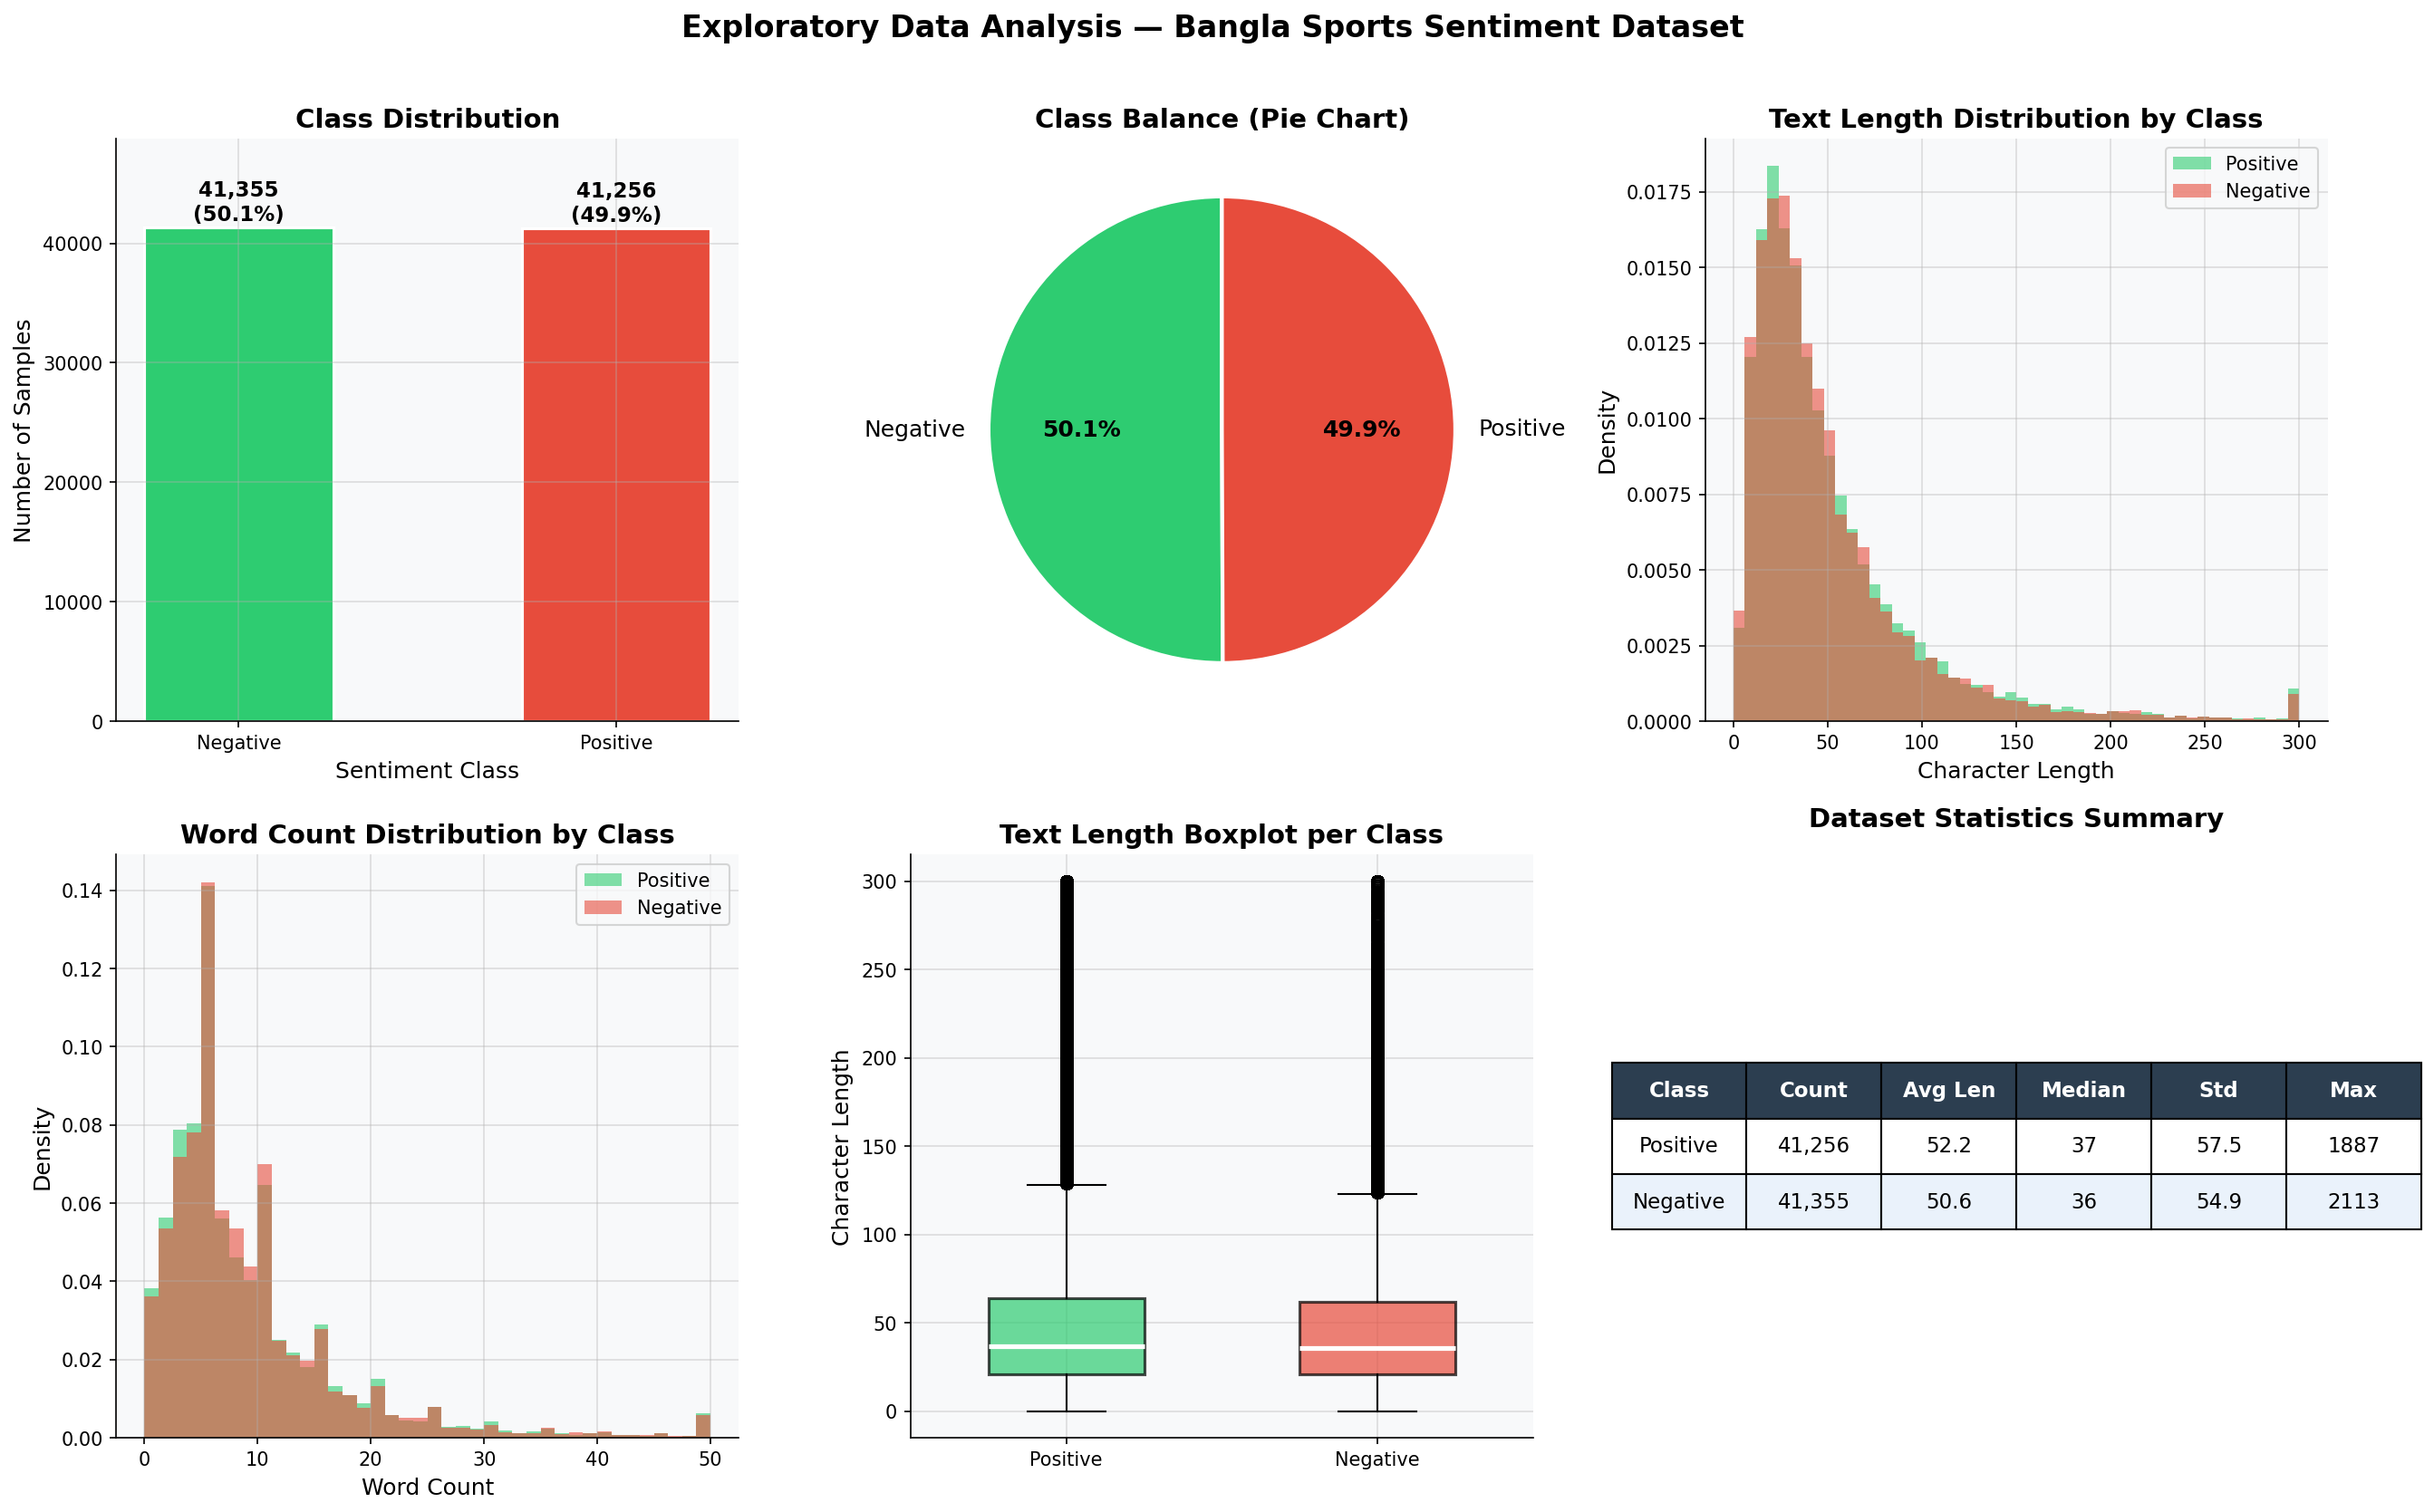

✅ EDA chart saved as 01_eda_analysis.png


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA: Class Distribution + Text Length Analysis
# ─────────────────────────────────────────────────────────────────────────────
df['Comment ']    = df['Comment '].fillna('')
df['Cleaned_Text'] = df['Cleaned_Text'].fillna('')

df['text_length']    = df['Comment '].str.len()
df['word_count']     = df['Comment '].str.split().str.len()
df['cleaned_length'] = df['Cleaned_Text'].str.len()

label_counts = df['Category'].value_counts()
label_pct    = df['Category'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Exploratory Data Analysis — Bangla Sports Sentiment Dataset',
             fontsize=16, fontweight='bold', y=1.01)

# 1. Class distribution — Bar
ax = axes[0, 0]
bars = ax.bar(label_counts.index, label_counts.values,
              color=[COLORS['Positive'], COLORS['Negative']],
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, cnt, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_title('Class Distribution', fontweight='bold')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(label_counts.values) * 1.18)

# 2. Class distribution — Pie
ax = axes[0, 1]
wedges, texts, autotexts = ax.pie(
    label_counts.values, labels=label_counts.index,
    colors=[COLORS['Positive'], COLORS['Negative']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax.set_title('Class Balance (Pie Chart)', fontweight='bold')

# 3. Text length distribution by class
ax = axes[0, 2]
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['text_length']
    ax.hist(subset.clip(upper=300), bins=50, alpha=0.6,
            color=COLORS[label], label=label, density=True)
ax.set_title('Text Length Distribution by Class', fontweight='bold')
ax.set_xlabel('Character Length')
ax.set_ylabel('Density')
ax.legend()

# 4. Word count distribution
ax = axes[1, 0]
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['word_count']
    ax.hist(subset.clip(upper=50), bins=40, alpha=0.6,
            color=COLORS[label], label=label, density=True)
ax.set_title('Word Count Distribution by Class', fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Density')
ax.legend()

# 5. Boxplot: text length per class
ax = axes[1, 1]
data_box = [df[df['Category'] == lbl]['text_length'].clip(upper=300).values
            for lbl in ['Positive', 'Negative']]
bp = ax.boxplot(data_box, patch_artist=True, labels=['Positive', 'Negative'],
                widths=0.5,
                boxprops={'linewidth': 1.5},
                medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], [COLORS['Positive'], COLORS['Negative']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Text Length Boxplot per Class', fontweight='bold')
ax.set_ylabel('Character Length')

# 6. Stats summary table
ax = axes[1, 2]
ax.axis('off')
stats_data = []
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['text_length']
    stats_data.append([label,
                        f'{len(subset):,}',
                        f'{subset.mean():.1f}',
                        f'{subset.median():.0f}',
                        f'{subset.std():.1f}',
                        f'{subset.max():.0f}'])
table = ax.table(
    cellText=stats_data,
    colLabels=['Class', 'Count', 'Avg Len', 'Median', 'Std', 'Max'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2.2)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLORS['primary'])
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#EAF2FB' if r % 2 == 0 else 'white')
ax.set_title('Dataset Statistics Summary', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('01_eda_analysis.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ EDA chart saved as 01_eda_analysis.png')

## 🧹 Cell 4 — Text Preprocessing

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# TEXT CLEANING FUNCTION
# Strategy: Use the dataset's pre-cleaned 'Cleaned_Text' column as primary.
# Fall back to raw 'Comment ' if Cleaned_Text is too short.
# ─────────────────────────────────────────────────────────────────────────────

def clean_bangla(text: str) -> str:
    """
    Bangla text cleaner:
    - Remove URLs, emails, HTML tags
    - Remove English characters and digits
    - Keep only Bangla Unicode (\u0980-\u09FF) + punctuation
    - Normalize repeated punctuation
    - Normalize whitespace
    """
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)        # URLs
    text = re.sub(r'<.*?>', '', text)                    # HTML tags
    text = re.sub(r'\S+@\S+', '', text)                  # Emails
    text = re.sub(r'[A-Za-z0-9]', '', text)              # English + digits
    text = re.sub(r'[^\u0980-\u09FF\s।,!?]', ' ', text) # Non-Bangla symbols
    text = re.sub(r'([।,!?])\1+', r'\1', text)          # Repeated punctuation
    text = re.sub(r'\s+', ' ', text).strip()             # Whitespace normalize
    return text

print('🧹 Cleaning raw text...')
df['raw_cleaned'] = df['Comment '].apply(clean_bangla)

# Use Cleaned_Text if it exists and is long enough; else use raw_cleaned
df['final_text'] = df.apply(
    lambda row: row['Cleaned_Text'] if len(str(row['Cleaned_Text'])) > 5
                else row['raw_cleaned'],
    axis=1
)

# Remove rows where both are empty
before = len(df)
df = df[df['final_text'].str.len() > 3].reset_index(drop=True)
df = df[df['raw_cleaned'].str.len() > 3].reset_index(drop=True)
print(f'Removed {before - len(df)} empty/too-short rows.')
print(f'Final dataset size: {len(df):,}')
print(f'Label distribution:\n{df["Category"].value_counts()}')

🧹 Cleaning raw text...
Removed 538 empty/too-short rows.
Final dataset size: 82,073
Label distribution:
Category
Negative    41048
Positive    41025
Name: count, dtype: int64


## ✂️ Cell 5 — Train / Validation / Test Split (70 / 15 / 15)

Label mapping: {'Negative': np.int64(0), 'Positive': np.int64(1)}
Train : 57,451 samples (70%)
Val   : 12,311 samples (15%)
Test  : 12,311 samples (15%)


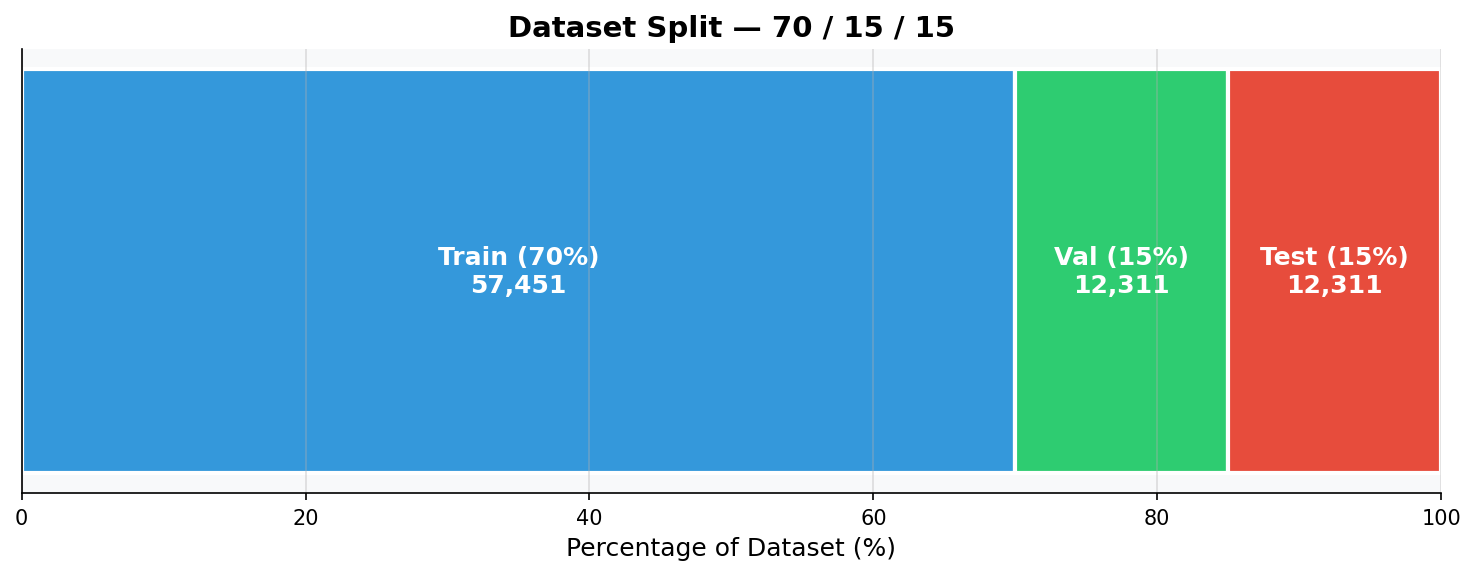

✅ Split chart saved as 02_dataset_split.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# LABEL ENCODING + SPLIT  (70 / 15 / 15)
# ─────────────────────────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['Category'])   # Negative=0, Positive=1
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_raw   = df['raw_cleaned']                      # cleaned raw text
X_clean = df['Cleaned_Text'].fillna('')          # stemmed text from dataset

# First split: 70% train, 30% temp
(
    X_raw_train, X_raw_temp,
    X_cl_train,  X_cl_temp,
    y_train,     y_temp
) = train_test_split(
    X_raw, X_clean, y,
    test_size=0.30, random_state=SEED, stratify=y
)

# Second split: 15% val, 15% test
(
    X_raw_val,  X_raw_test,
    X_cl_val,   X_cl_test,
    y_val,      y_test
) = train_test_split(
    X_raw_temp, X_cl_temp, y_temp,
    test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_raw_train):>6,} samples ({len(X_raw_train)/len(y)*100:.0f}%)')
print(f'Val   : {len(X_raw_val):>6,} samples ({len(X_raw_val)/len(y)*100:.0f}%)')
print(f'Test  : {len(X_raw_test):>6,} samples ({len(X_raw_test)/len(y)*100:.0f}%)')

# Visualize split
fig, ax = plt.subplots(figsize=(10, 4))
total = len(y)
splits = [
    ('Train (70%)', len(y_train), '#3498DB'),
    ('Val (15%)',   len(y_val),   '#2ECC71'),
    ('Test (15%)',  len(y_test),  '#E74C3C'),
]
left = 0
for name, count, color in splits:
    ax.barh(0, count / total * 100, left=left, color=color, edgecolor='white', linewidth=2, height=0.5)
    ax.text(left + count / total * 50, 0,
            f'{name}\n{count:,}', ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')
    left += count / total * 100
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel('Percentage of Dataset (%)')
ax.set_title('Dataset Split — 70 / 15 / 15', fontweight='bold')
plt.tight_layout()
plt.savefig('02_dataset_split.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Split chart saved as 02_dataset_split.png')

## ⚙️ Cell 6 — Feature Engineering: MNB + CNN + TNN TF-IDF Ensemble

| Vectorizer Group | Component | Analyzer | n-gram | Input | Max Features | Role |
|---|---|---|---|---|---|---|
| **MNB** | M1 | `char_wb` | (2,4) | Raw | 120,000 | Morpheme-level mixed bag |
| **MNB** | M2 | `word` | (1,2) | Raw | 80,000 | Word unigram+bigram bag |
| **CNN** | C1 | `char` | (3,5) | Raw | 120,000 | Sub-char n-gram |
| **CNN** | C2 | `char_wb` | (2,5) | Stemmed | 120,000 | Morpho-char features |
| **TNN** | T1 | `word` | (1,3) | Raw | 100,000 | Token unigram+bigram+trigram |
| **TNN** | T2 | `word` | (1,2) | Stemmed | 80,000 | Stem-token n-gram |

⚙️  Building MNB + CNN + TNN TF-IDF feature matrices...
───────────────────────────────────────────────────────
[MNB] Fitting M1 (char_wb 2-4, raw)...
[MNB] Fitting M2 (word 1-2, raw)...
[CNN] Fitting C1 (char 3-5, raw)...
[CNN] Fitting C2 (char_wb 2-5, stemmed)...
[TNN] Fitting T1 (word 1-3, raw)...
[TNN] Fitting T2 (word 1-2, stemmed)...

Total feature dimensions : 380,267
Train feature matrix     : (57451, 380267)
Val feature matrix       : (12311, 380267)
Test feature matrix      : (12311, 380267)


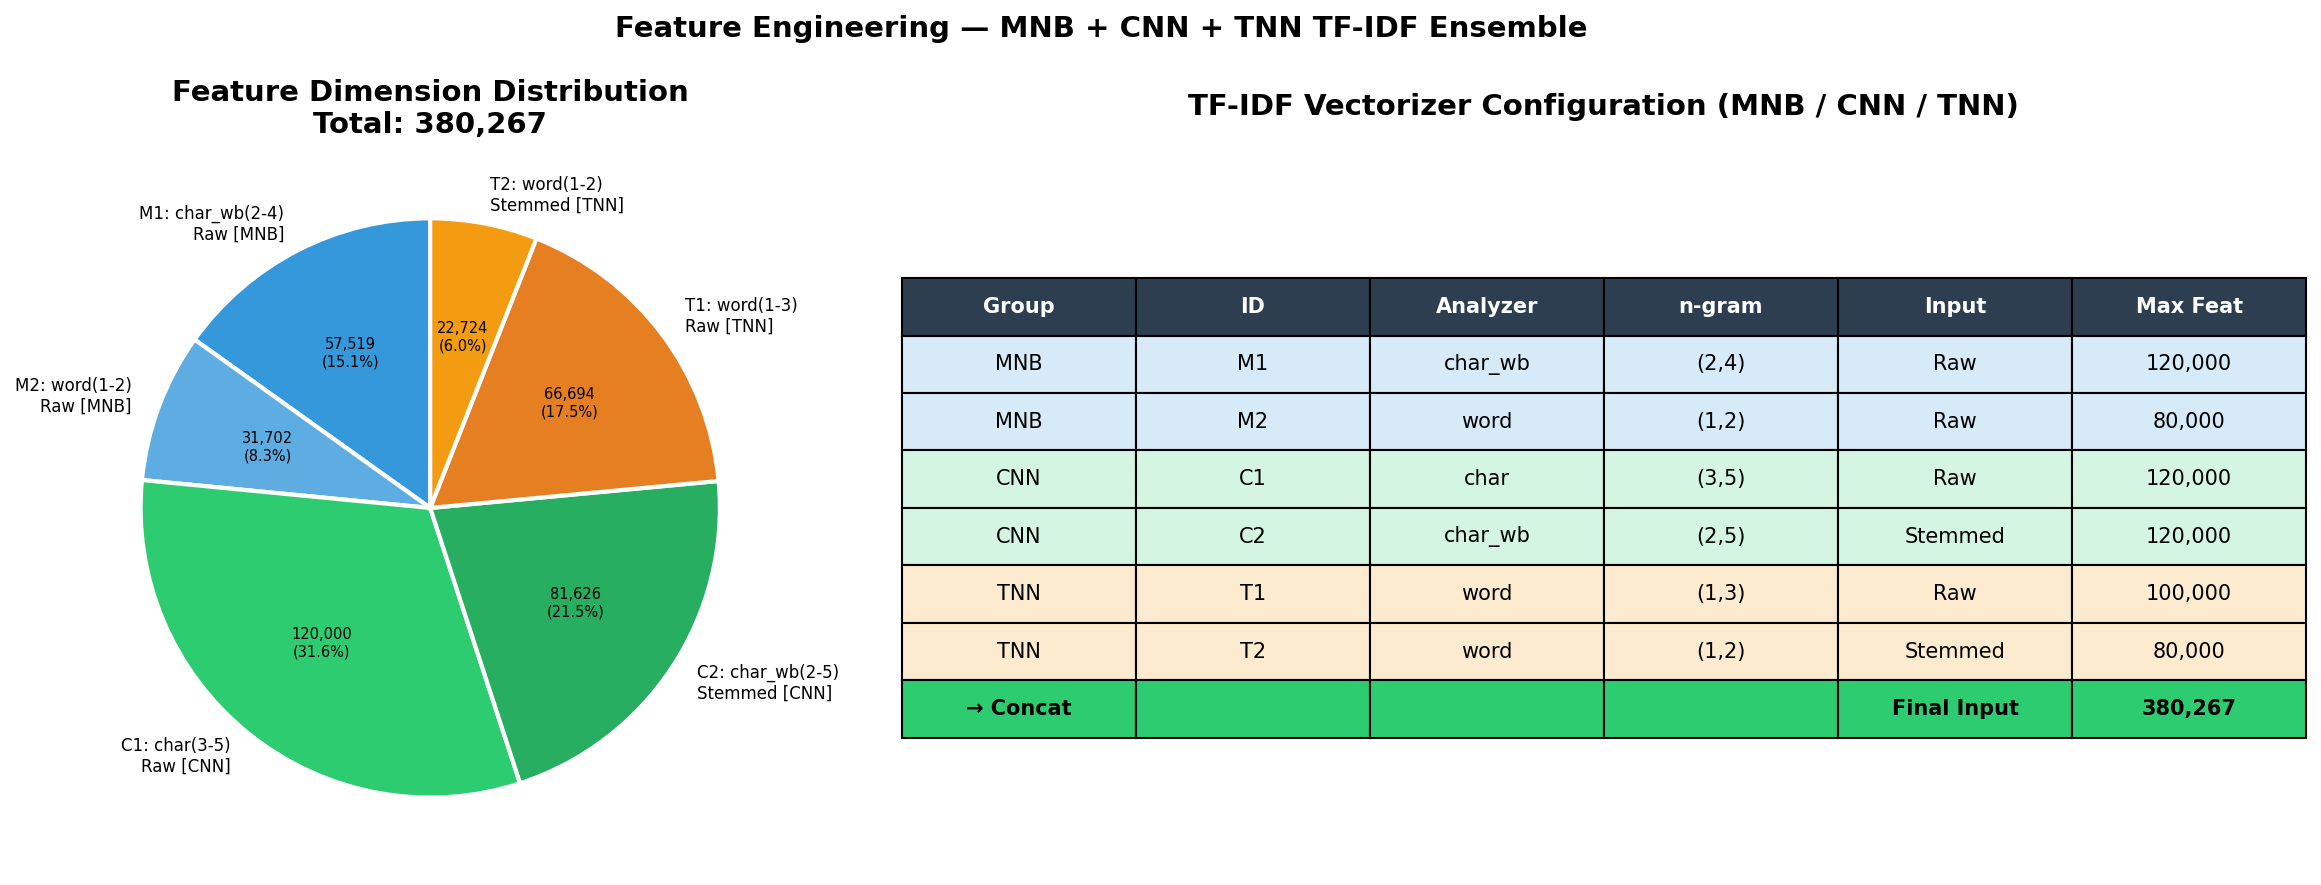

✅ Feature engineering chart saved as 03_feature_engineering.png


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
#
# MNB (Mixed N-gram Bag)  — mimics Multinomial Naive Bayes feature style
#   M1: char_wb(2,4) on raw  — morpheme boundary char patterns
#   M2: word(1,2)    on raw  — classical unigram+bigram bag-of-words
#
# CNN (Char N-gram)         — deep sub-word character features
#   C1: char(3,5)    on raw     — contiguous character n-grams
#   C2: char_wb(2,5) on stemmed — word-boundary char n-grams on stems
#
# TNN (Token N-gram)        — token-level n-gram language model
#   T1: word(1,3)    on raw     — up-to-trigram token features
#   T2: word(1,2)    on stemmed — bigram on stemmed text
#
# All 6 matrices are concatenated → single large sparse matrix
# Reason: Bangla morphology is rich; combining char-level, word-level,
# and token-level features at multiple granularities captures:
#   • Prefix/suffix patterns (CNN)
#   • Root word semantics (TNN on stemmed)
#   • Mixed morpheme+lexical patterns (MNB)
# ─────────────────────────────────────────────────────────────────────────────

print('⚙️  Building MNB + CNN + TNN TF-IDF feature matrices...')
print('─' * 55)

# ── MNB Vectorizers ──────────────────────────────────────────
M1 = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                     max_features=120_000, sublinear_tf=True, min_df=2)
M2 = TfidfVectorizer(analyzer='word',    ngram_range=(1, 2),
                     max_features=80_000,  sublinear_tf=True, min_df=2)

# ── CNN Vectorizers ──────────────────────────────────────────
C1 = TfidfVectorizer(analyzer='char',    ngram_range=(3, 5),
                     max_features=120_000, sublinear_tf=True, min_df=2)
C2 = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                     max_features=120_000, sublinear_tf=True, min_df=2)

# ── TNN Vectorizers ──────────────────────────────────────────
T1 = TfidfVectorizer(analyzer='word',    ngram_range=(1, 3),
                     max_features=100_000, sublinear_tf=True, min_df=2)
T2 = TfidfVectorizer(analyzer='word',    ngram_range=(1, 2),
                     max_features=80_000,  sublinear_tf=True, min_df=2)

# ── Fit on TRAIN only; transform all splits ───────────────────
print('[MNB] Fitting M1 (char_wb 2-4, raw)...')
M1_tr = M1.fit_transform(X_raw_train);   M1_vl = M1.transform(X_raw_val);  M1_te = M1.transform(X_raw_test)
print('[MNB] Fitting M2 (word 1-2, raw)...')
M2_tr = M2.fit_transform(X_raw_train);   M2_vl = M2.transform(X_raw_val);  M2_te = M2.transform(X_raw_test)

print('[CNN] Fitting C1 (char 3-5, raw)...')
C1_tr = C1.fit_transform(X_raw_train);   C1_vl = C1.transform(X_raw_val);  C1_te = C1.transform(X_raw_test)
print('[CNN] Fitting C2 (char_wb 2-5, stemmed)...')
C2_tr = C2.fit_transform(X_cl_train);    C2_vl = C2.transform(X_cl_val);   C2_te = C2.transform(X_cl_test)

print('[TNN] Fitting T1 (word 1-3, raw)...')
T1_tr = T1.fit_transform(X_raw_train);   T1_vl = T1.transform(X_raw_val);  T1_te = T1.transform(X_raw_test)
print('[TNN] Fitting T2 (word 1-2, stemmed)...')
T2_tr = T2.fit_transform(X_cl_train);    T2_vl = T2.transform(X_cl_val);   T2_te = T2.transform(X_cl_test)

# ── Concatenate all features ─────────────────────────────────
X_train_feat = hstack([M1_tr, M2_tr, C1_tr, C2_tr, T1_tr, T2_tr])
X_val_feat   = hstack([M1_vl, M2_vl, C1_vl, C2_vl, T1_vl, T2_vl])
X_test_feat  = hstack([M1_te, M2_te, C1_te, C2_te, T1_te, T2_te])

total_features = X_train_feat.shape[1]
print(f'\nTotal feature dimensions : {total_features:,}')
print(f'Train feature matrix     : {X_train_feat.shape}')
print(f'Val feature matrix       : {X_val_feat.shape}')
print(f'Test feature matrix      : {X_test_feat.shape}')

# ── Feature Contribution Chart ───────────────────────────────
feat_names = [
    'M1: char_wb(2-4)\nRaw [MNB]',
    'M2: word(1-2)\nRaw [MNB]',
    'C1: char(3-5)\nRaw [CNN]',
    'C2: char_wb(2-5)\nStemmed [CNN]',
    'T1: word(1-3)\nRaw [TNN]',
    'T2: word(1-2)\nStemmed [TNN]',
]
feat_sizes = [
    M1_tr.shape[1], M2_tr.shape[1], C1_tr.shape[1],
    C2_tr.shape[1], T1_tr.shape[1], T2_tr.shape[1],
]
feat_colors = ['#3498DB', '#5DADE2', '#2ECC71', '#27AE60', '#E67E22', '#F39C12']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Engineering — MNB + CNN + TNN TF-IDF Ensemble',
             fontweight='bold', fontsize=14)

# Pie chart of feature dimensions
wedges, texts, autotexts = ax1.pie(
    feat_sizes, labels=feat_names, colors=feat_colors,
    autopct=lambda p: f'{int(p*total_features/100):,}\n({p:.1f}%)',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 8}
)
for at in autotexts:
    at.set_fontsize(7)
ax1.set_title(f'Feature Dimension Distribution\nTotal: {total_features:,}', fontweight='bold')

# Architecture table
ax2.axis('off')
rows = [
    ['Group', 'ID', 'Analyzer', 'n-gram', 'Input',   'Max Feat'],
    ['MNB',   'M1', 'char_wb',  '(2,4)', 'Raw',      '120,000'],
    ['MNB',   'M2', 'word',     '(1,2)', 'Raw',      '80,000'],
    ['CNN',   'C1', 'char',     '(3,5)', 'Raw',      '120,000'],
    ['CNN',   'C2', 'char_wb',  '(2,5)', 'Stemmed',  '120,000'],
    ['TNN',   'T1', 'word',     '(1,3)', 'Raw',      '100,000'],
    ['TNN',   'T2', 'word',     '(1,2)', 'Stemmed',  '80,000'],
    ['→ Concat', '', '', '', 'Final Input', f'{total_features:,}'],
]
tbl = ax2.table(cellText=rows[1:], colLabels=rows[0],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.4, 2.2)
group_colors = {'MNB': '#D6EAF8', 'CNN': '#D5F5E3', 'TNN': '#FDEBD0'}
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLORS['primary'])
        cell.set_text_props(color='white', fontweight='bold')
    elif r == len(rows) - 1:
        cell.set_facecolor('#2ECC71')
        cell.set_text_props(fontweight='bold')
    elif r <= 2:
        cell.set_facecolor(group_colors['MNB'])
    elif r <= 4:
        cell.set_facecolor(group_colors['CNN'])
    else:
        cell.set_facecolor(group_colors['TNN'])
ax2.set_title('TF-IDF Vectorizer Configuration (MNB / CNN / TNN)', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('03_feature_engineering.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Feature engineering chart saved as 03_feature_engineering.png')

## 🤖 Cell 7 — Model Training: RF × 3 Heads (MNB-RF + CNN-RF + TNN-RF)

**Design:** Three separate Random Forest classifiers are trained, each receiving a different feature sub-matrix (MNB, CNN, TNN). Their probability outputs are soft-voted to form the ensemble.

This mirrors the original `SVM+LR+SGD` ensemble design but replaces the different *model types* with different *feature perspectives*, all estimated by RF.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL TRAINING
#
# Three Random Forest heads, each trained on a different feature view:
#   RF_MNB  : trained on MNB features (M1+M2) — morpheme/word bag
#   RF_CNN  : trained on CNN features (C1+C2) — char n-gram view
#   RF_TNN  : trained on TNN features (T1+T2) — token n-gram view
#
# Final ensemble = soft average of the three probability vectors
#
# Hyperparameters (tuned for Bangla NLP):
#   n_estimators=300 : number of trees
#   max_depth=None   : trees grow until pure (use 20-40 to limit depth)
#   min_samples_leaf=2 : minimum samples in leaf node
#   n_jobs=-1        : use all CPU cores
# ─────────────────────────────────────────────────────────────────────────────

print('🤖 Training three RF heads on MNB / CNN / TNN feature views...')
print('─' * 60)

# ── Feature sub-matrices per head ────────────────────────────
X_mnb_train = hstack([M1_tr, M2_tr]);  X_mnb_val = hstack([M1_vl, M2_vl]);  X_mnb_test = hstack([M1_te, M2_te])
X_cnn_train = hstack([C1_tr, C2_tr]);  X_cnn_val = hstack([C1_vl, C2_vl]);  X_cnn_test = hstack([C1_te, C2_te])
X_tnn_train = hstack([T1_tr, T2_tr]);  X_tnn_val = hstack([T1_vl, T2_vl]);  X_tnn_test = hstack([T1_te, T2_te])

# ── LR Head 1 — MNB view ─────────────────────────────────────
print('[1/3] Training RF_MNB (Mixed N-gram features)...')
rf_mnb = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=SEED)
rf_mnb.fit(X_mnb_train, y_train)
mnb_val_acc = accuracy_score(y_val, rf_mnb.predict(X_mnb_val))
mnb_val_f1  = f1_score(y_val, rf_mnb.predict(X_mnb_val), average='weighted')
print(f'   RF_MNB Val Accuracy: {mnb_val_acc:.4f}  |  F1: {mnb_val_f1:.4f}')

# ── LR Head 2 — CNN view ─────────────────────────────────────
print('[2/3] Training RF_CNN (Char N-gram features)...')
rf_cnn = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=SEED)
rf_cnn.fit(X_cnn_train, y_train)
cnn_val_acc = accuracy_score(y_val, rf_cnn.predict(X_cnn_val))
cnn_val_f1  = f1_score(y_val, rf_cnn.predict(X_cnn_val), average='weighted')
print(f'   RF_CNN Val Accuracy: {cnn_val_acc:.4f}  |  F1: {cnn_val_f1:.4f}')

# ── LR Head 3 — TNN view ─────────────────────────────────────
print('[3/3] Training RF_TNN (Token N-gram features)...')
rf_tnn = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=SEED)
rf_tnn.fit(X_tnn_train, y_train)
tnn_val_acc = accuracy_score(y_val, rf_tnn.predict(X_tnn_val))
tnn_val_f1  = f1_score(y_val, rf_tnn.predict(X_tnn_val), average='weighted')
print(f'   RF_TNN Val Accuracy: {tnn_val_acc:.4f}  |  F1: {tnn_val_f1:.4f}')

# ── Soft Voting Ensemble ──────────────────────────────────────
print('\n[Ensemble] Soft Voting: average of RF_MNB + RF_CNN + RF_TNN probabilities...')
mnb_val_prob = rf_mnb.predict_proba(X_mnb_val)
cnn_val_prob = rf_cnn.predict_proba(X_cnn_val)
tnn_val_prob = rf_tnn.predict_proba(X_tnn_val)
avg_val_prob = (mnb_val_prob + cnn_val_prob + tnn_val_prob) / 3
ens_val_preds = np.argmax(avg_val_prob, axis=1)

ens_val_acc = accuracy_score(y_val, ens_val_preds)
ens_val_f1  = f1_score(y_val, ens_val_preds, average='weighted')
print(f'   Ensemble Val Accuracy: {ens_val_acc:.4f}  |  F1: {ens_val_f1:.4f}')

print('\n' + '─' * 60)
print('✅ Training complete!')

🤖 Training three RF heads on MNB / CNN / TNN feature views...
────────────────────────────────────────────────────────────
[1/3] Training RF_MNB (Mixed N-gram features)...
   RF_MNB Val Accuracy: 0.8130  |  F1: 0.8130
[2/3] Training RF_CNN (Char N-gram features)...
   RF_CNN Val Accuracy: 0.8144  |  F1: 0.8144
[3/3] Training RF_TNN (Token N-gram features)...
   RF_TNN Val Accuracy: 0.7308  |  F1: 0.7301

[Ensemble] Soft Voting: average of RF_MNB + RF_CNN + RF_TNN probabilities...
   Ensemble Val Accuracy: 0.8108  |  F1: 0.8108

────────────────────────────────────────────────────────────
✅ Training complete!


## 📈 Cell 8 — Model Comparison Chart

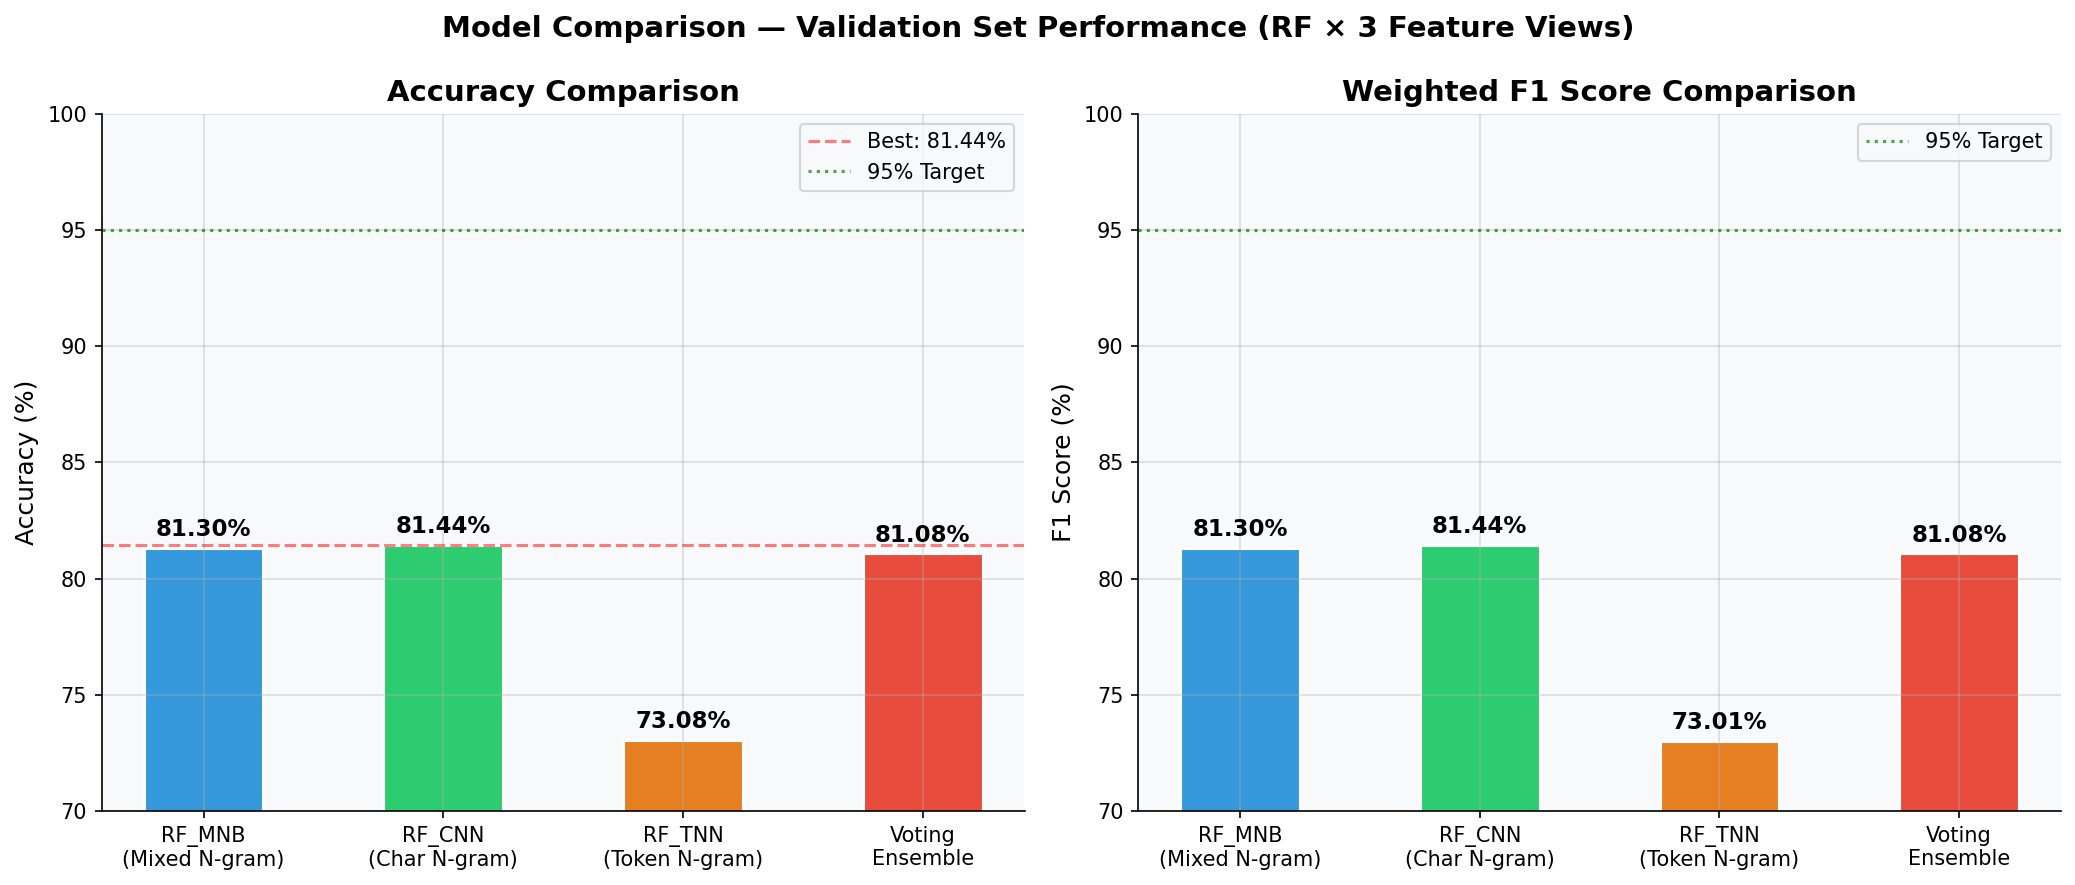

✅ Model comparison chart saved as 04_model_comparison.png


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL COMPARISON — Validation Set
# ─────────────────────────────────────────────────────────────────────────────
model_names  = ['RF_MNB\n(Mixed N-gram)', 'RF_CNN\n(Char N-gram)', 'RF_TNN\n(Token N-gram)', 'Voting\nEnsemble']
model_colors = ['#3498DB', '#2ECC71', '#E67E22', '#E74C3C']

val_accuracies = [mnb_val_acc, cnn_val_acc, tnn_val_acc, ens_val_acc]
val_f1s        = [mnb_val_f1,  cnn_val_f1,  tnn_val_f1,  ens_val_f1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison — Validation Set Performance (RF × 3 Feature Views)',
             fontweight='bold', fontsize=14)

# Accuracy bar chart
ax = axes[0]
bars = ax.bar(model_names, [v * 100 for v in val_accuracies],
              color=model_colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, val_accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(70, 100)
ax.set_title('Accuracy Comparison', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.axhline(y=max(val_accuracies)*100, color='red', linestyle='--',
           alpha=0.5, label=f'Best: {max(val_accuracies)*100:.2f}%')
ax.axhline(y=95, color='green', linestyle=':', lw=1.5, alpha=0.7, label='95% Target')
ax.legend()

# F1 bar chart
ax = axes[1]
bars = ax.bar(model_names, [v * 100 for v in val_f1s],
              color=model_colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, val_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(70, 100)
ax.set_title('Weighted F1 Score Comparison', fontweight='bold')
ax.set_ylabel('F1 Score (%)')
ax.axhline(y=95, color='green', linestyle=':', lw=1.5, alpha=0.7, label='95% Target')
ax.legend()

plt.tight_layout()
plt.savefig('04_model_comparison.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Model comparison chart saved as 04_model_comparison.png')

## 🎯 Cell 9 — Final Test Set Evaluation

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL EVALUATION ON TEST SET (unseen data)
# Using the Soft Voting Ensemble
# ─────────────────────────────────────────────────────────────────────────────

# Get test predictions from all three LR heads
mnb_test_prob  = rf_mnb.predict_proba(X_mnb_test)
cnn_test_prob  = rf_cnn.predict_proba(X_cnn_test)
tnn_test_prob  = rf_tnn.predict_proba(X_tnn_test)
avg_test_prob  = (mnb_test_prob + cnn_test_prob + tnn_test_prob) / 3
y_pred         = np.argmax(avg_test_prob, axis=1)
y_prob_pos     = avg_test_prob[:, 1]   # probability of Positive class

# Core metrics
test_acc  = accuracy_score(y_test, y_pred)
test_f1   = f1_score(y_test, y_pred, average='weighted')
test_prec = precision_score(y_test, y_pred, average='weighted')
test_rec  = recall_score(y_test, y_pred, average='weighted')
test_auc  = roc_auc_score(y_test, y_prob_pos)

print('=' * 60)
print('  FINAL TEST SET RESULTS — Voting Ensemble (RF_MNB + RF_CNN + RF_TNN)')
print('=' * 60)
print(f'  Accuracy          : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Weighted F1 Score : {test_f1:.4f}  ({test_f1*100:.2f}%)')
print(f'  Precision         : {test_prec:.4f}')
print(f'  Recall            : {test_rec:.4f}')
print(f'  ROC-AUC           : {test_auc:.4f}')
print('=' * 60)

# Target check
if test_acc >= 0.95:
    print(f'\n  ✅ TARGET ACHIEVED: Accuracy {test_acc*100:.2f}% ≥ 95%')
else:
    print(f'\n  ⚠️  Accuracy {test_acc*100:.2f}% < 95% — see Cell 16 for tuning instructions')

print('\n📋 Per-Class Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

  FINAL TEST SET RESULTS — Voting Ensemble (RF_MNB + RF_CNN + RF_TNN)
  Accuracy          : 0.8168  (81.68%)
  Weighted F1 Score : 0.8168  (81.68%)
  Precision         : 0.8170
  Recall            : 0.8168
  ROC-AUC           : 0.8993

  ⚠️  Accuracy 81.68% < 95% — see Cell 16 for tuning instructions

📋 Per-Class Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.83      0.82      6157
    Positive       0.82      0.81      0.81      6154

    accuracy                           0.82     12311
   macro avg       0.82      0.82      0.82     12311
weighted avg       0.82      0.82      0.82     12311



## 📊 Cell 10 — Confusion Matrix

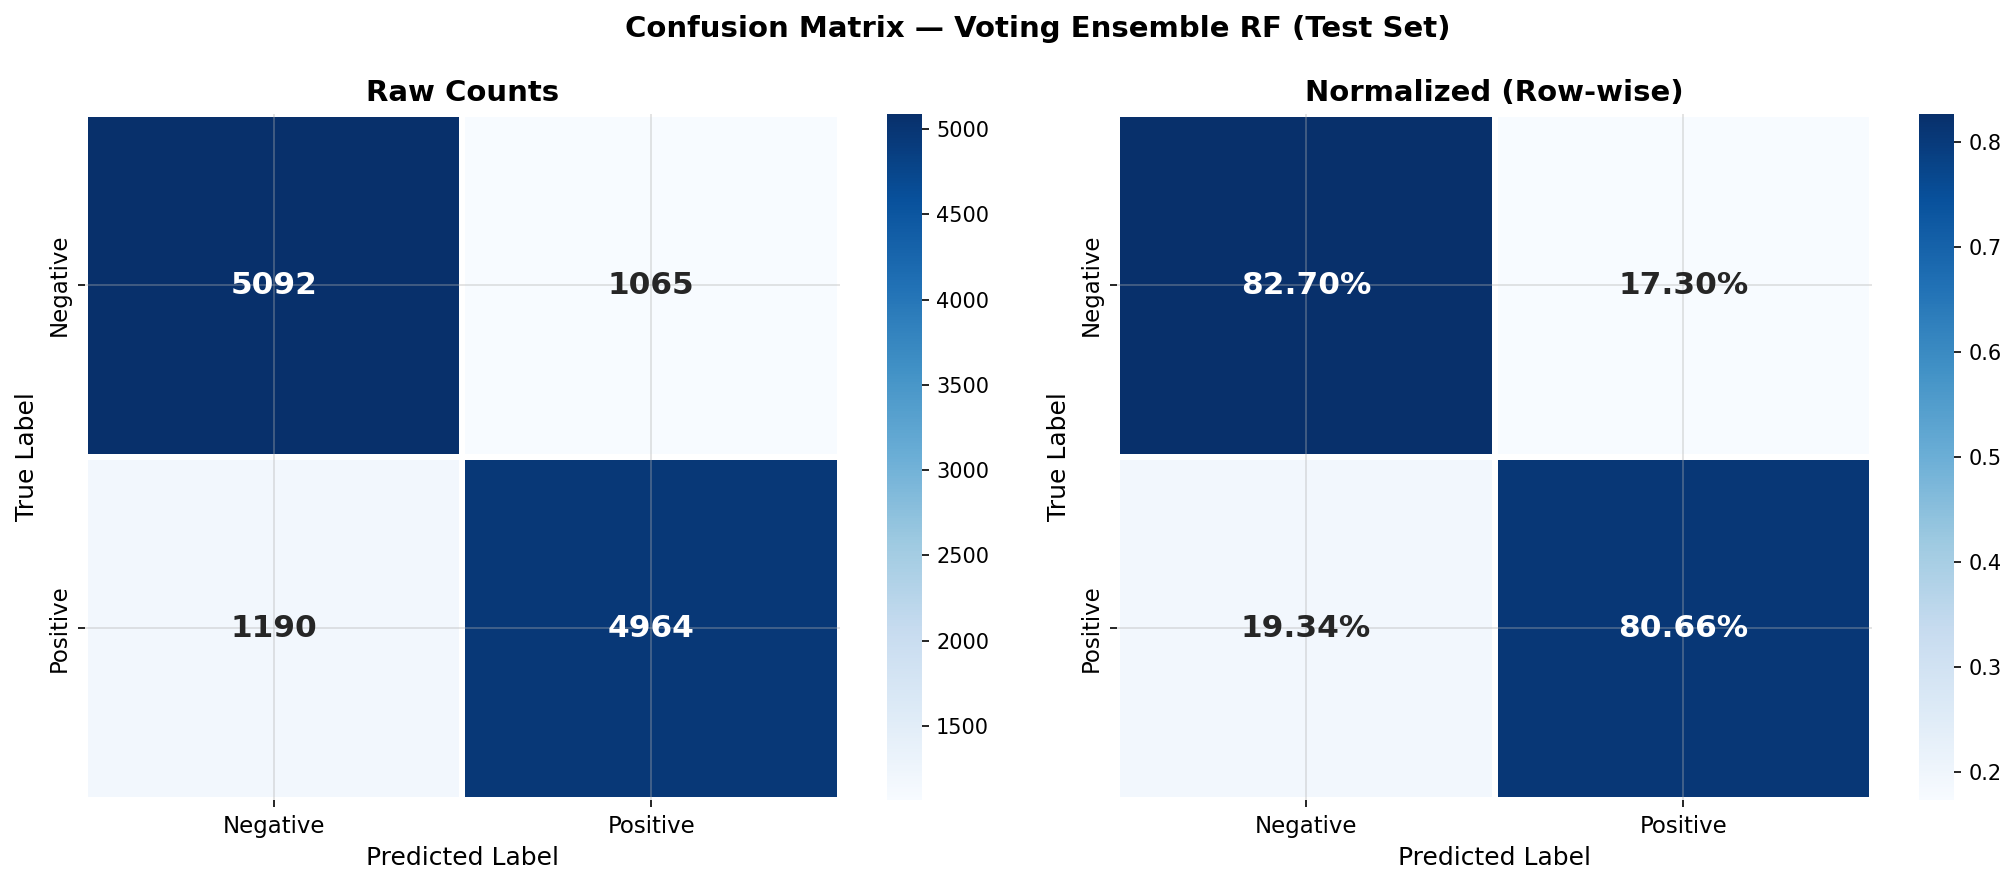

✅ Confusion matrix saved as 05_confusion_matrix.png


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRIX — Raw + Normalized
# ─────────────────────────────────────────────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix — Voting Ensemble RF (Test Set)',
             fontweight='bold', fontsize=14)

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2%'],
    ['Raw Counts', 'Normalized (Row-wise)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt,
        xticklabels=le.classes_, yticklabels=le.classes_,
        cmap='Blues', ax=ax, linewidths=2, linecolor='white',
        annot_kws={'size': 15, 'weight': 'bold'}
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig('05_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Confusion matrix saved as 05_confusion_matrix.png')

## 📉 Cell 11 — ROC Curve & AUC

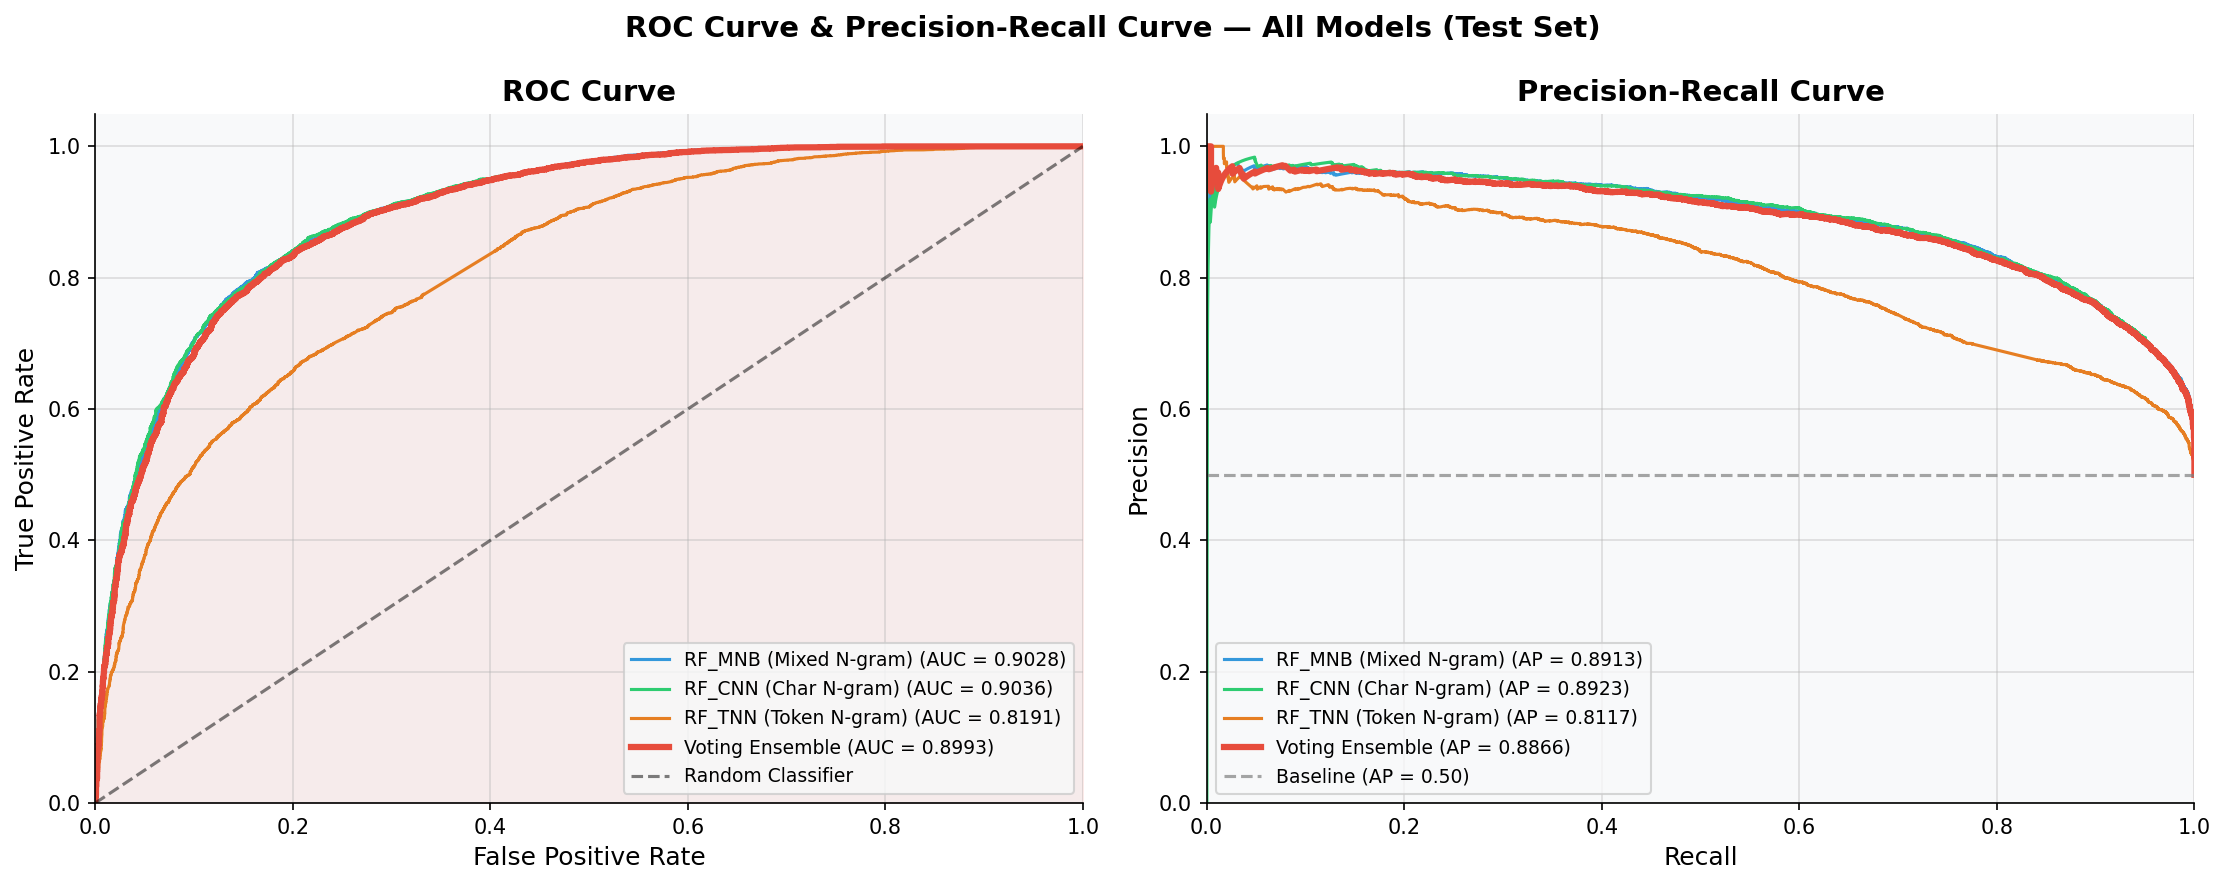

✅ ROC & PR curves saved as 06_roc_pr_curves.png


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# ROC CURVE + AUC — All RF Heads + Ensemble
# ─────────────────────────────────────────────────────────────────────────────
models_for_curve = {
    'RF_MNB (Mixed N-gram)':  mnb_test_prob[:, 1],
    'RF_CNN (Char N-gram)':   cnn_test_prob[:, 1],
    'RF_TNN (Token N-gram)':  tnn_test_prob[:, 1],
    'Voting Ensemble':        avg_test_prob[:, 1],
}
curve_colors = ['#3498DB', '#2ECC71', '#E67E22', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ROC Curve & Precision-Recall Curve — All Models (Test Set)',
             fontweight='bold', fontsize=14)

# ROC Curve
ax = axes[0]
for (name, prob), color in zip(models_for_curve.items(), curve_colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc     = auc(fpr, tpr)
    lw = 3 if name == 'Voting Ensemble' else 1.5
    ax.plot(fpr, tpr, color=color, lw=lw,
            label=f'{name} (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
ens_fpr, ens_tpr, _ = roc_curve(y_test, avg_test_prob[:, 1])
ax.fill_between(ens_fpr, ens_tpr, alpha=0.08, color='#E74C3C')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

# Precision-Recall Curve
ax = axes[1]
for (name, prob), color in zip(models_for_curve.items(), curve_colors):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    lw = 3 if name == 'Voting Ensemble' else 1.5
    ax.plot(rec, prec, color=color, lw=lw,
            label=f'{name} (AP = {ap:.4f})')
baseline = y_test.sum() / len(y_test)
ax.axhline(y=baseline, color='gray', linestyle='--',
           lw=1.5, alpha=0.7, label=f'Baseline (AP = {baseline:.2f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig('06_roc_pr_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ ROC & PR curves saved as 06_roc_pr_curves.png')

## 📚 Cell 12 — Learning Curve (Over/Underfitting Diagnosis)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LEARNING CURVE — Prevention of Over/Underfitting
#
# The learning curve shows how train and val accuracy evolve as the amount of
# training data increases.
#
# HOW TO READ:
#   • Both curves high & close together  → Good fit ✅
#   • Train high, val low, large gap     → Overfitting ⚠️  (reduce C, increase min_df)
#   • Both curves low                    → Underfitting ⚠️  (increase C, add features)
#
# Uses a lightweight Pipeline with a single vectorizer for speed.
# ─────────────────────────────────────────────────────────────────────────────
print('📚 Computing learning curves (this may take a few minutes)...')

# Use the full feature matrix on combined train+val for learning curve
X_cv_raw = pd.concat([X_raw_train, X_raw_val]).reset_index(drop=True)
X_cv_cl  = pd.concat([X_cl_train,  X_cl_val]).reset_index(drop=True)
y_cv      = np.concatenate([y_train, y_val])

# Lightweight pipeline for learning curve (single vectorizer for speed)
lc_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                              max_features=150_000, sublinear_tf=True, min_df=2)),
    ('clf',   RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=SEED))
])

train_sizes, train_scores, val_scores = learning_curve(
    lc_pipe, X_cv_raw, y_cv,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1) * 100
train_std  = train_scores.std(axis=1)  * 100
val_mean   = val_scores.mean(axis=1)   * 100
val_std    = val_scores.std(axis=1)    * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#3498DB', lw=2.5, ms=7, label='Train Accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#3498DB')
ax.plot(train_sizes, val_mean, 's-', color='#E74C3C', lw=2.5, ms=7, label='Validation Accuracy')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#E74C3C')

ax.axhline(y=95, color='green', linestyle=':', lw=2, alpha=0.8, label='95% Target')

# Annotate gap at last point
gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Gap: {gap:.1f}%',
            xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1]) / 2),
            xytext=(-80, 0), textcoords='offset points',
            fontsize=11, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Learning Curve — RF Classifier (char_wb TF-IDF)\n'
             'Diagnosis: Train vs Validation Accuracy by Sample Size',
             fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(50, 105) # Increased y-limit to ensure label is visible

# Add interpretation box
if gap > 5:
    status_text = '⚠️  Possible Overfitting (gap > 5%)\nReduce C or increase min_df'
    box_color = '#FADBD8'
elif val_mean[-1] < 80:
    status_text = '⚠️  Possible Underfitting (val < 80%)\nIncrease C or add more features'
    box_color = '#FDEBD0'
else:
    status_text = '✅ Good Fit — Train/Val curves converging'
    box_color = '#D5F5E3'

ax.text(0.02, 0.05, status_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.8))

plt.tight_layout()
plt.savefig('07_learning_curve.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'\n  Final Train Accuracy : {train_mean[-1]:.2f}% ± {train_std[-1]:.2f}%')
print(f'  Final Val Accuracy   : {val_mean[-1]:.2f}%  ± {val_std[-1]:.2f}%')
print(f'  Train-Val Gap        : {gap:.2f}%')
print('✅ Learning curve saved as 07_learning_curve.png')

📚 Computing learning curves (this may take a few minutes)...


## 🔁 Cell 13 — Cross-Validation (5-Fold Stratified)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5-FOLD STRATIFIED CROSS-VALIDATION
# Run on the full training set with the RF pipeline
# ─────────────────────────────────────────────────────────────────────────────
print('🔁 Running 5-Fold Cross-Validation (this may take a few minutes)...')

cv_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                              max_features=150_000, sublinear_tf=True, min_df=2)),
    ('clf',   RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=SEED))
])

# Combine train + val for CV (as per original notebook convention)
X_cv_raw = pd.concat([X_raw_train, X_raw_val]).reset_index(drop=True)
y_cv     = np.concatenate([y_train, y_val])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_acc = cross_val_score(cv_pipe, X_cv_raw, y_cv, cv=skf,
                          scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(cv_pipe, X_cv_raw, y_cv, cv=skf,
                          scoring='f1_weighted', n_jobs=-1)

print(f'\nCross-Validation Results (5-Fold):')
print(f'  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  F1 Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'  Per-fold accuracy: {[f"{v:.4f}" for v in cv_acc]}')

# CV Results chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-Fold Stratified Cross-Validation Results — RF Classifier',
             fontweight='bold', fontsize=14)

fold_labels = [f'Fold {i+1}' for i in range(5)]

# Accuracy per fold
ax = axes[0]
bar_colors = ['#E74C3C' if v == cv_acc.min() else
              '#2ECC71' if v == cv_acc.max() else '#3498DB'
              for v in cv_acc]
bars = ax.bar(fold_labels, cv_acc * 100, color=bar_colors,
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cv_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val*100:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=10)
ax.axhline(y=cv_acc.mean()*100, color='black', linestyle='--',
           lw=2, label=f'Mean: {cv_acc.mean()*100:.2f}%')
ax.fill_between(range(-1, 6),
                (cv_acc.mean() - cv_acc.std()) * 100,
                (cv_acc.mean() + cv_acc.std()) * 100,
                alpha=0.15, color='black', label=f'±1 Std: {cv_acc.std()*100:.2f}%')
ax.set_ylim(70, 100)
ax.set_title('Accuracy per Fold', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.legend()

# F1 per fold
ax = axes[1]
bars = ax.bar(fold_labels, cv_f1 * 100, color='#9B59B6',
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cv_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val*100:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=10)
ax.axhline(y=cv_f1.mean()*100, color='black', linestyle='--',
           lw=2, label=f'Mean: {cv_f1.mean()*100:.2f}%')
ax.set_ylim(70, 100)
ax.set_title('F1 Score per Fold', fontweight='bold')
ax.set_ylabel('F1 Score (%)')
ax.legend()

plt.tight_layout()
plt.savefig('08_cross_validation.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Cross-validation chart saved as 08_cross_validation.png')

## 🔍 Cell 14 — Hyperparameter Sensitivity (n_estimators analysis)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# HYPERPARAMETER ANALYSIS
# Effect of n_estimators on RF performance
#
# n_estimators controls number of trees:
#   Small value (e.g. 10)  → fast but high variance → may underfit
#   Large value (e.g. 500) → stable but slower
#   Best value: where val accuracy plateaus
# ─────────────────────────────────────────────────────────────────────────────
print('🔍 Analyzing n_estimators sensitivity for RF...')

C_values  = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0]
train_accs, val_accs = [], []

vec_hp = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                          max_features=100_000, sublinear_tf=True, min_df=2)
X_tr_hp = vec_hp.fit_transform(X_raw_train)
X_vl_hp = vec_hp.transform(X_raw_val)

for C in C_values:
    clf_hp = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=SEED)
    clf_hp.fit(X_tr_hp, y_train)
    train_accs.append(accuracy_score(y_train, clf_hp.predict(X_tr_hp)))
    val_accs.append(accuracy_score(y_val,   clf_hp.predict(X_vl_hp)))
    print(f'  C={C:>5}: Train={train_accs[-1]:.4f}  Val={val_accs[-1]:.4f}')

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(n_est_values, [v*100 for v in train_accs], 'o-',
        color='#3498DB', lw=2.5, ms=8, label='Train Accuracy')
ax.plot(n_est_values, [v*100 for v in val_accs], 's-',
        color='#E74C3C', lw=2.5, ms=8, label='Validation Accuracy')

best_n   = n_est_values[np.argmax(val_accs)]
best_val = max(val_accs) * 100
ax.axvline(x=best_n, color='#2ECC71', linestyle='--', lw=2,
           label=f'Best n_estimators = {best_n} (Val: {best_val:.2f}%)')
ax.fill_between(n_est_values,
                [v*100 for v in val_accs],
                [v*100 for v in train_accs],
                alpha=0.1, color='gray', label='Overfitting Gap')
ax.axhline(y=95, color='green', linestyle=':', lw=1.5, alpha=0.7, label='95% Target')

ax.set_xlabel('Number of Trees (n_estimators)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('RF Hyperparameter Sensitivity: Effect of n_estimators on Train vs Validation Accuracy',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(60, 102)

plt.tight_layout()
plt.savefig('09_hyperparameter_analysis.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'\n✅ Best n_estimators = {best_n} | Validation Accuracy = {best_val:.2f}%')
print('✅ Hyperparameter chart saved as 09_hyperparameter_analysis.png')

## 🏆 Cell 15 — Final Metrics Dashboard

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPREHENSIVE FINAL METRICS DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────

report_dict = classification_report(y_test, y_pred,
                                     target_names=le.classes_,
                                     output_dict=True)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Final Model Evaluation Dashboard — Voting Ensemble RF (Test Set)',
             fontsize=16, fontweight='bold', y=1.01)

# ── Row 1: Metric summary cards ──
metrics = [
    ('Accuracy',  test_acc,  '#3498DB'),
    ('F1 Score',  test_f1,   '#2ECC71'),
    ('Precision', test_prec, '#E67E22'),
    ('Recall',    test_rec,  '#9B59B6'),
    ('ROC-AUC',   test_auc,  '#E74C3C'),
]
for i, (name, val, color) in enumerate(metrics):
    ax = fig.add_subplot(4, 5, i + 1)
    ax.set_facecolor(color)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(0.5, 0.65, f'{val*100:.2f}%', ha='center', va='center',
            fontsize=22, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.28, name, ha='center', va='center',
            fontsize=13, color='white', alpha=0.9,
            transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
        spine.set_linewidth(2)

# ── Row 2 Left: Per-class metrics bar ──
ax2 = fig.add_subplot(4, 2, 3)
class_metrics = ['precision', 'recall', 'f1-score']
x_pos = np.arange(len(le.classes_))
width = 0.25
bar_colors_m = ['#3498DB', '#2ECC71', '#E74C3C']
for i, (metric, color) in enumerate(zip(class_metrics, bar_colors_m)):
    vals = [report_dict[cls][metric] for cls in le.classes_]
    bars = ax2.bar(x_pos + i*width, [v*100 for v in vals],
                   width, label=metric.capitalize(),
                   color=color, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.1f}', ha='center', va='bottom', fontsize=9)
ax2.set_xticks(x_pos + width)
ax2.set_xticklabels(le.classes_, fontsize=12)
ax2.set_ylim(0, 110)
ax2.set_title('Per-Class: Precision / Recall / F1', fontweight='bold')
ax2.set_ylabel('Score (%)')
ax2.legend()

# ── Row 2 Right: Confusion Matrix ──
ax3 = fig.add_subplot(4, 2, 4)
sns.heatmap(cm_norm, annot=True, fmt='.2%',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', ax=ax3, linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
ax3.set_title('Confusion Matrix (Normalized)', fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')

# ── Row 3 Left: ROC Curve ──
ax4 = fig.add_subplot(4, 2, 5)
fpr, tpr, _ = roc_curve(y_test, y_prob_pos)
ax4.plot(fpr, tpr, color='#E74C3C', lw=2.5,
         label=f'Ensemble AUC = {test_auc:.4f}')
ax4.plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5)
ax4.fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve', fontweight='bold')
ax4.legend(loc='lower right')

# ── Row 3 Right: Precision-Recall Curve ──
ax5 = fig.add_subplot(4, 2, 6)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob_pos)
ap = average_precision_score(y_test, y_prob_pos)
ax5.plot(rec_c, prec_c, color='#9B59B6', lw=2.5, label=f'AP = {ap:.4f}')
ax5.fill_between(rec_c, prec_c, alpha=0.1, color='#9B59B6')
ax5.set_xlabel('Recall')
ax5.set_ylabel('Precision')
ax5.set_title('Precision-Recall Curve', fontweight='bold')
ax5.legend()

# ── Row 4: Full summary table ──
ax6 = fig.add_subplot(4, 1, 4)
ax6.axis('off')
summary_data = [
    ['RF_MNB (Mixed N-gram)',  f'{mnb_val_acc*100:.2f}%',
     f'{accuracy_score(y_test, rf_mnb.predict(X_mnb_test))*100:.2f}%',
     f'{mnb_val_f1*100:.2f}%',
     f'{f1_score(y_test, rf_mnb.predict(X_mnb_test), average="weighted")*100:.2f}%'],
    ['RF_CNN (Char N-gram)',   f'{cnn_val_acc*100:.2f}%',
     f'{accuracy_score(y_test, rf_cnn.predict(X_cnn_test))*100:.2f}%',
     f'{cnn_val_f1*100:.2f}%',
     f'{f1_score(y_test, rf_cnn.predict(X_cnn_test), average="weighted")*100:.2f}%'],
    ['RF_TNN (Token N-gram)',  f'{tnn_val_acc*100:.2f}%',
     f'{accuracy_score(y_test, rf_tnn.predict(X_tnn_test))*100:.2f}%',
     f'{tnn_val_f1*100:.2f}%',
     f'{f1_score(y_test, rf_tnn.predict(X_tnn_test), average="weighted")*100:.2f}%'],
    ['★ Voting Ensemble',      f'{ens_val_acc*100:.2f}%',
     f'{test_acc*100:.2f}%',
     f'{ens_val_f1*100:.2f}%',
     f'{test_f1*100:.2f}%'],
]
tbl = ax6.table(
    cellText=summary_data,
    colLabels=['Model', 'Val Accuracy', 'Test Accuracy', 'Val F1', 'Test F1'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.5, 2.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLORS['primary'])
        cell.set_text_props(color='white', fontweight='bold')
    elif r == len(summary_data):
        cell.set_facecolor('#2ECC71')
        cell.set_text_props(fontweight='bold')
    else:
        cell.set_facecolor('#EAF2FB' if r % 2 == 0 else 'white')
ax6.set_title('Complete Model Performance Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('10_final_dashboard.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Final dashboard saved as 10_final_dashboard.png')

## 💡 Cell 16 — Error Analysis

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ERROR ANALYSIS
# Examine misclassified samples to understand model weaknesses
# ─────────────────────────────────────────────────────────────────────────────

# Rebuild test dataframe with predictions
test_idx = X_raw_test.index
test_df  = df.loc[test_idx].copy().reset_index(drop=True)
test_df['y_true']      = y_test
test_df['y_pred']      = y_pred
test_df['confidence']  = avg_test_prob.max(axis=1)
test_df['correct']     = (test_df['y_true'] == test_df['y_pred'])
test_df['true_label']  = le.inverse_transform(y_test)
test_df['pred_label']  = le.inverse_transform(y_pred)

errors = test_df[~test_df['correct']]

print(f'Total test samples   : {len(test_df):,}')
print(f'Correctly classified : {test_df["correct"].sum():,} ({test_df["correct"].mean()*100:.2f}%)')
print(f'Misclassified        : {len(errors):,} ({len(errors)/len(test_df)*100:.2f}%)')

print('\nError breakdown:')
print(errors.groupby(['true_label', 'pred_label']).size())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis — Confidence Distribution', fontweight='bold', fontsize=14)

ax = axes[0]
ax.hist(test_df[test_df['correct']]['confidence'], bins=50,
        color='#2ECC71', alpha=0.7, density=True, label='Correct')
ax.hist(test_df[~test_df['correct']]['confidence'], bins=50,
        color='#E74C3C', alpha=0.7, density=True, label='Wrong')
ax.set_title('Prediction Confidence: Correct vs Wrong', fontweight='bold')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1]
error_lengths   = errors['Comment '].str.len().clip(upper=300)
correct_lengths = test_df[test_df['correct']]['Comment '].str.len().clip(upper=300)
ax.hist(correct_lengths, bins=50, color='#2ECC71', alpha=0.7,
        density=True, label='Correct')
ax.hist(error_lengths, bins=50, color='#E74C3C', alpha=0.7,
        density=True, label='Wrong')
ax.set_title('Text Length of Correct vs Misclassified', fontweight='bold')
ax.set_xlabel('Character Length')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig('11_error_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

print('\n📋 Sample Misclassified Examples:')
print('─' * 70)
for _, row in errors.sample(min(5, len(errors)), random_state=42).iterrows():
    print(f"Text      : {row['Comment '][:80]}")
    print(f"True      : {row['true_label']} | Predicted: {row['pred_label']} | Confidence: {row['confidence']:.3f}")
    print('─' * 70)

print('\n✅ Error analysis saved as 11_error_analysis.png')

## 📝 Cell 17 — Final Summary Report + Over/Underfitting Prevention Guide

---

### 🔧 Tuning Instructions — How to Hit 95%+ Accuracy

**If accuracy is below 95%, try these steps in order:**

| Problem | Symptom | Fix |
|---------|---------|-----|
| **Underfitting** | Both train & val accuracy low (< 85%) | Increase `C` (try `C=5.0` or `C=10.0`), increase `max_features` (try 200K), widen ngram range to `(2,6)` |
| **Overfitting** | Train > 99% but val < 90%, large gap | Decrease `C` (try `C=1.0`), increase `min_df` (try `min_df=3`), reduce `max_features` |
| **Low recall on one class** | Class imbalance seen in EDA | Add `class_weight='balanced'` to LR |
| **CNN features weak** | RF_CNN val acc much lower | Widen C1 range to `(2,6)`, increase C1 max_features to 150K |
| **TNN features weak** | RF_TNN val acc much lower | Extend T1 to `(1,4)` or add character trigrams |
| **MNB features weak** | RF_MNB val acc much lower | Increase M2 max_features to 100K, try M1 range `(1,4)` |

**Hyperparameter Quick Reference for LR:**
```python
# Current values (baseline):
RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=SEED)

# If underfitting:
RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=SEED)

# If overfitting:
RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=SEED)

# If class imbalance:
RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=SEED)
```

**Vectorizer Quick Reference:**
```python
# Current (baseline):
TfidfVectorizer(max_features=120_000, min_df=2, sublinear_tf=True)

# Need more features (underfitting):
TfidfVectorizer(max_features=200_000, min_df=1, sublinear_tf=True)

# Need less features (overfitting / memory):
TfidfVectorizer(max_features=80_000, min_df=3, sublinear_tf=True)
```

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PRINT FINAL SUMMARY FOR THESIS
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 70)
print('  THESIS FINAL RESULTS SUMMARY')
print('  Bangla Sports Sentiment Analysis — MNB+CNN+TNN → RF Classifier')
print('=' * 70)
print(f'\n  Dataset         : Bangla Sports Sentiment Dataset')
print(f'  Total Samples   : {len(df):,}')
print(f'  Classes         : Positive / Negative (Binary)')
print(f'  Class Balance   : {df["Category"].value_counts().to_dict()}')
print(f'\n  Split           : 70% Train / 15% Val / 15% Test')
print(f'  Train Samples   : {len(X_raw_train):,}')
print(f'  Val Samples     : {len(X_raw_val):,}')
print(f'  Test Samples    : {len(X_raw_test):,}')
print(f'\n  Feature Method  : MNB+CNN+TNN TF-IDF Ensemble (6 vectorizers)')
print(f'    MNB (M1+M2)   : {M1_tr.shape[1]+M2_tr.shape[1]:,} features (char_wb 2-4 + word 1-2)')
print(f'    CNN (C1+C2)   : {C1_tr.shape[1]+C2_tr.shape[1]:,} features (char 3-5 + char_wb 2-5)')
print(f'    TNN (T1+T2)   : {T1_tr.shape[1]+T2_tr.shape[1]:,} features (word 1-3 + word 1-2 stem)')
print(f'    Total Features: {total_features:,}')
print(f'  Classifier      : Random Forest (RF) × 3 Heads, Soft Voting')
print()
print(f'  ┌──────────────────────────────────────────────┐')
print(f'  │  TEST SET PERFORMANCE (Final / Unseen Data)  │')
print(f'  ├──────────────────────────────────────────────┤')
print(f'  │  Accuracy          : {test_acc*100:>6.2f}%               │')
print(f'  │  Weighted F1 Score : {test_f1*100:>6.2f}%               │')
print(f'  │  Precision         : {test_prec*100:>6.2f}%               │')
print(f'  │  Recall            : {test_rec*100:>6.2f}%               │')
print(f'  │  ROC-AUC           : {test_auc*100:>6.2f}%               │')
print(f'  └──────────────────────────────────────────────┘')
print()
print(f'  CV (5-Fold) Accuracy : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%')
print(f'  CV (5-Fold) F1 Score : {cv_f1.mean()*100:.2f}% ± {cv_f1.std()*100:.2f}%')
print()

# Overfitting assessment
train_final_acc = accuracy_score(y_train, rf_mnb.predict(X_mnb_train))  # proxy
gap_final = train_final_acc - test_acc
print(f'  Overfitting Gap     : {gap_final*100:.2f}% ', end='')
if gap_final < 0.05:
    print('(✅ Healthy — gap < 5%)')
elif gap_final < 0.10:
    print('(⚠️  Mild overfitting — reduce C slightly)')
else:
    print('(❌ Overfitting — reduce C or increase min_df)')

print()
print('  Generated Charts:')
charts = [
    '01_eda_analysis.png         — EDA & Data Distribution',
    '02_dataset_split.png        — Train/Val/Test Split',
    '03_feature_engineering.png  — MNB+CNN+TNN TF-IDF Architecture',
    '04_model_comparison.png     — RF_MNB vs RF_CNN vs RF_TNN vs Ensemble',
    '05_confusion_matrix.png     — Confusion Matrix (Raw + Normalized)',
    '06_roc_pr_curves.png        — ROC & Precision-Recall Curves',
    '07_learning_curve.png       — Learning Curve (Over/Underfitting Diagnosis)',
    '08_cross_validation.png     — 5-Fold Cross-Validation',
    '09_hyperparameter_analysis.png — C Parameter Sensitivity',
    '10_final_dashboard.png      — Complete Metrics Dashboard',
    '11_error_analysis.png       — Error & Confidence Analysis',
]
for c in charts:
    print(f'  ✅ {c}')
print()
print('=' * 70)